### 이미지 매칭
- 두 이미지를 비교해서 짝이 맞는 같은 형태의 객체가 있는지 찾아내는 기술
- Keypoint: 이미지의 특징점
- Descriptor: Keypoint 주변의 지역적인 이미지 정보를 숫자 벡터로 표현

### ORB(Oriented FAST and Rotated BRIEF) 특징점 검출기:
- FAST 알고리즘을 이용해 Keypoint 검출
- BRIEF 알고리즘을 이용해 Descriptor 생성
- Oriented & Rotated: Keypoint의 방향성과 Descriptor의 회전 개념을 추가

In [1]:
import cv2
import numpy as np
from PIL import Image

def show(image):
    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return Image.fromarray(rgb)

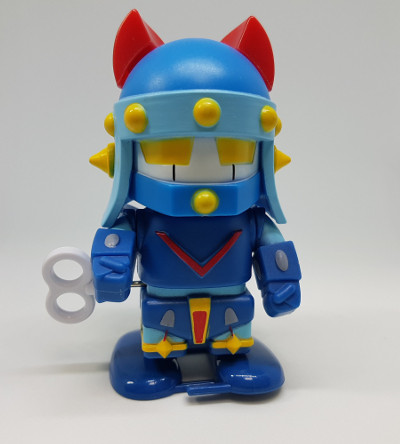

In [6]:
# Feature Descriptor
img1 = cv2.imread('../data/taekwonv1.jpg') # 비교할 이미지 로드
img2 = cv2.imread('../data/figures2.jpg')
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY) # 특징점 검출을 위해 흑백으로
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

show(img1)

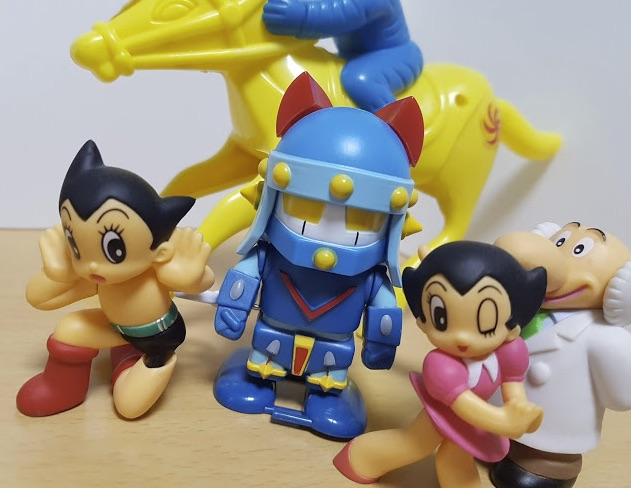

In [7]:
show(img2)

In [8]:
# ORB(Oriented FAST and Rotated BRIEF) 특징점 검출기
detector = cv2.ORB_create() # 검출기 생성

# 각 이미지의 키포인트(kp)와 디스크립터(desc)를 추출
kp1, desc1 = detector.detectAndCompute(gray1, None)
kp2, desc2 = detector.detectAndCompute(gray2, None)

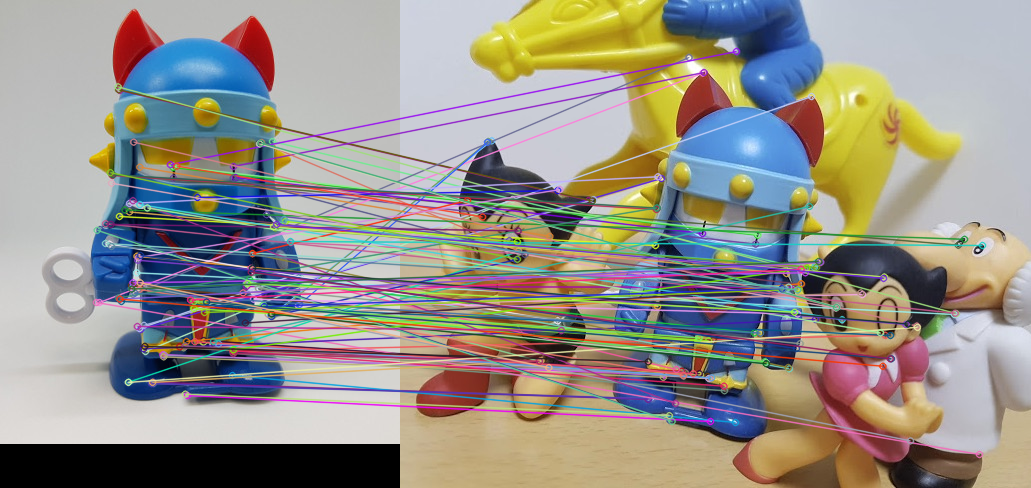

In [ ]:
# 특징 매칭
# 2개의 그림에서 특징들이 서로 일치하는 부분을 매칭
matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = matcher.match(desc1, desc2)

# 매칭된 결과를 거리의 오름차순으로 정렬(가까울 수록 좋은 매칭)
matches = sorted(matches, key=lambda x:x.distance)

# 결과 시각화
res1 = cv2.drawMatches(img1, kp1, img2, kp2, matches, None,
                       flags=cv2.DRAW_MATCHES_FLAGS_NOT_DRAW_SINGLE_POINTS)
show(res1) # 두 장의 사진이 다른 방향과 각도에서 촬영한 것이므로 완전히 일치하지 않음 -> 호모그래피

In [ ]:
# 호모그래피
# 투시 변환을 통해 방향과 각도를 맞춤

# 두 이미지에서 매칭된 점의 좌표들을 추출
src_pts = np.float32([ kp1[m.queryIdx].pt for m in matches ]) 
dst_pts = np.float32([ kp2[m.trainIdx].pt for m in matches ])

# RANSAC 알고리즘으로 두 좌표들을 최대한 맞출 수 있는 변환 행렬을 계산
# mask: RANSAC 알고리즘으로 걸러진 좋은 매칭점을 1로 표현
# (임계값 5.0 이하의 점들만 포함)
mtrx, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

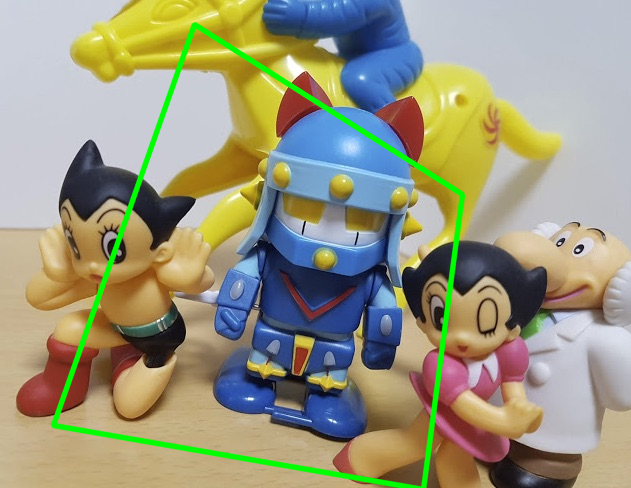

In [11]:
# 시각화
h, w = img1.shape[:2] # 원본 이미지 크기
pts = np.float32([ [[0,0]],[[0,h-1]],[[w-1,h-1]],[[w-1,0]] ]) # 원본 이미지의 네 모서리 좌표
dst = cv2.perspectiveTransform(pts, mtrx) # ..가 img2에 어떻게 변환되는지

# 시각화
img2 = cv2.polylines(img2,[np.int32(dst)],True,(0, 255, 0),3, cv2.LINE_AA)
show(img2)

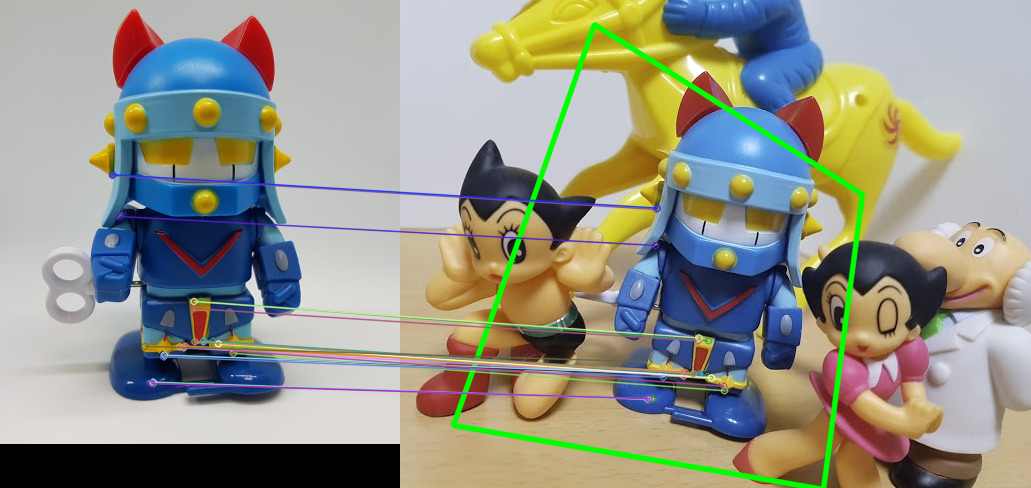

In [12]:
# 좋은 매칭점만 보기
matchesMask = mask.ravel().tolist() # RANSAC 알고리즘으로 걸러진 좋은 매칭점은 1
res2 = cv2.drawMatches(img1, kp1, img2, kp2, matches, None, # ..만 시각화
                     matchesMask = matchesMask,
                     flags=cv2.DRAW_MATCHES_FLAGS_NOT_DRAW_SINGLE_POINTS)
show(res2)

In [13]:
# 좋은 매칭점의 개수(적으면 물체가 없다고 판단할 수 있음)
sum(matchesMask)

27